# Регрессия: ансамблевые модели и МГУА

**Датасет:** Medical Insurance Cost — предсказание стоимости медицинской страховки (`charges`).


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.neural_network import MLPRegressor
import gmdh

sns.set_theme(style='whitegrid')

## Загрузка и EDA

In [2]:
df = pd.read_csv('insurance.csv')
print(df.shape)
print(df.isnull().sum())
df.describe(include='all')

(1338, 7)
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


d:\Учеба\3 Курс\6 Семестр\ТМО\MLT_2026\venv311\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
d:\Учеба\3 Курс\6 Семестр\ТМО\MLT_2026\venv311\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


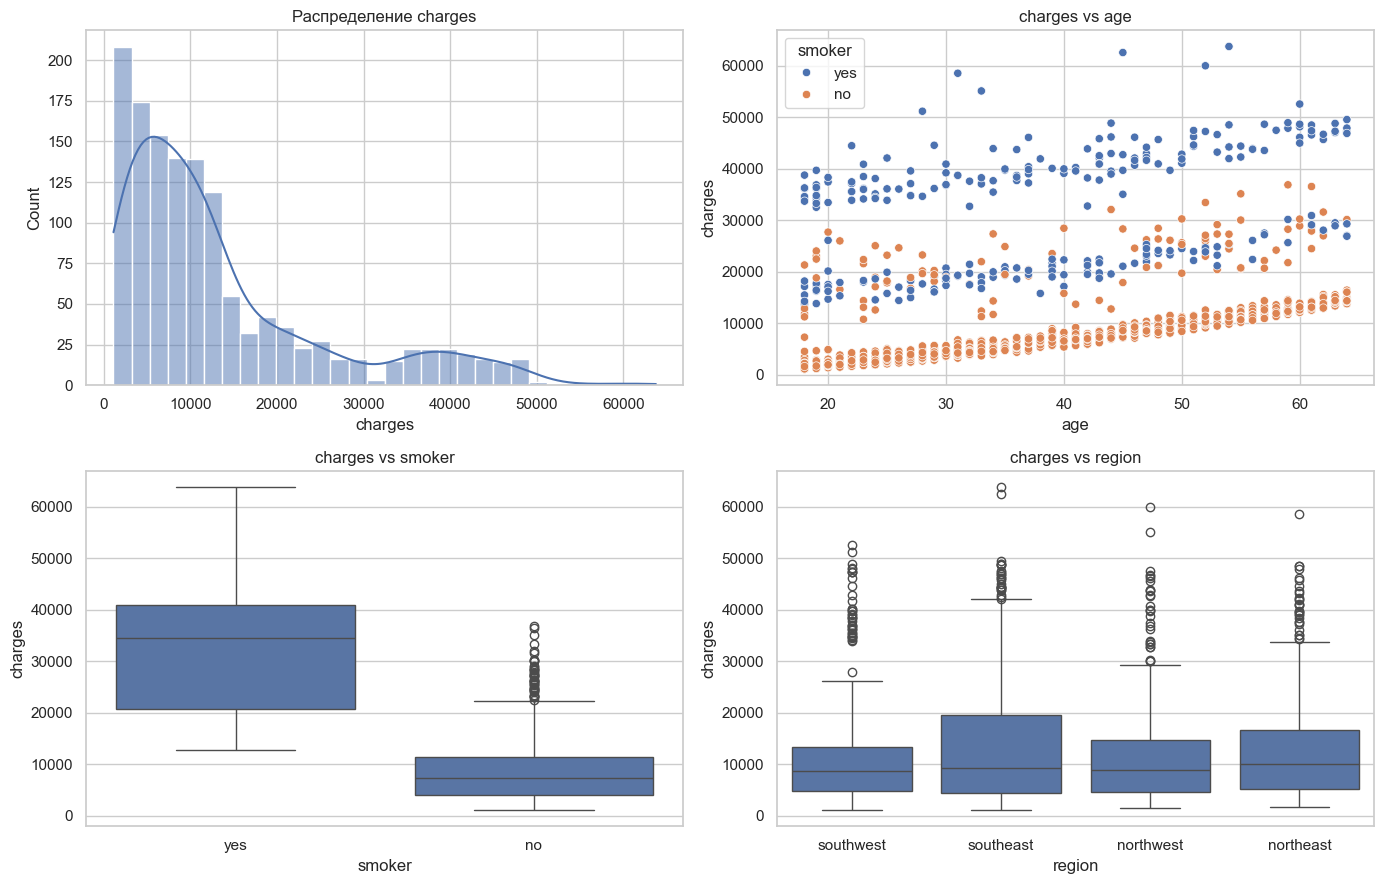

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df['charges'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Распределение charges')

sns.scatterplot(data=df, x='age', y='charges', hue='smoker', ax=axes[0, 1])
axes[0, 1].set_title('charges vs age')

sns.boxplot(data=df, x='smoker', y='charges', ax=axes[1, 0])
axes[1, 0].set_title('charges vs smoker')

sns.boxplot(data=df, x='region', y='charges', ax=axes[1, 1])
axes[1, 1].set_title('charges vs region')

plt.tight_layout()
plt.show()

## Предобработка и разбиение

In [4]:
TARGET = 'charges'
cat_cols = ['sex', 'smoker', 'region']
num_cols = ['age', 'bmi', 'children']

X = df.drop(columns=[TARGET])
y = df[TARGET].values

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
])

X_processed = preprocessor.fit_transform(X)
feature_names = num_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols))

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print('Признаки:', feature_names)

Train: (1070, 8), Test: (268, 8)
Признаки: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [5]:
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

def plot_actual_vs_pred(y_true, y_pred, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, alpha=0.6, edgecolors='white', linewidth=0.5)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1, label='Идеальный прогноз')
    ax.set_xlabel('Факт (charges)')
    ax.set_ylabel('Прогноз (charges)')
    ax.set_title(title)
    ax.legend()
    return ax

def plot_residuals(y_true, y_pred, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    residuals = y_true - y_pred
    ax.scatter(y_pred, residuals, alpha=0.6, edgecolors='white', linewidth=0.5)
    ax.axhline(0, color='k', linestyle='--', lw=1)
    ax.set_xlabel('Прогноз (charges)')
    ax.set_ylabel('Ошибка (факт − прогноз)')
    ax.set_title(title)
    return ax

## Stacking

In [6]:
stacking = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
        ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42)),
        ('ridge', Ridge(alpha=1.0)),
    ],
    final_estimator=Ridge(alpha=0.1),
    cv=5,
)

stacking.fit(X_train, y_train)
pred_stack = stacking.predict(X_test)
metrics_stack = evaluate(y_test, pred_stack)
print(metrics_stack)

{'RMSE': 4308.662056344884, 'MAE': 2411.422392830642, 'R2': 0.88042048049346}


## MLP

In [7]:
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=1000,
    random_state=42,
)

mlp.fit(X_train, y_train)
pred_mlp = mlp.predict(X_test)
metrics_mlp = evaluate(y_test, pred_mlp)
print(metrics_mlp)
print(f'Итераций: {mlp.n_iter_}')

{'RMSE': 5298.491867137087, 'MAE': 3587.5110059425992, 'R2': 0.8191675011038304}
Итераций: 1000


d:\Учеба\3 Курс\6 Семестр\ТМО\MLT_2026\venv311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


## МГУА: COMBI + MIA

In [8]:
model_combi = gmdh.Combi()
model_combi.fit(X_train, y_train)
pred_combi = model_combi.predict(X_test)

print(model_combi.get_best_polynomial())
metrics_combi = evaluate(y_test, pred_combi)
print(metrics_combi)

y = 3780.5235*x1 + 2009.6606*x2 + 409.5037*x3 + 24404.5829*x5 - 102.9225*x6 - 474.569*x7 - 761.9351*x8 + 8737.4176
{'RMSE': 5801.725754596319, 'MAE': 4140.575944114942, 'R2': 0.7831864942913891}


In [9]:
model_mia = gmdh.Mia()
model_mia.fit(X_train, y_train)
pred_mia = model_mia.predict(X_test)

print(model_mia.get_best_polynomial())
metrics_mia = evaluate(y_test, pred_mia)
print(metrics_mia)

f1_1 = 668.6045*x2 + 8743.796*x2*x5 - 512.8024*x2^2 + 23281.8023*x5^2 + 9092.2654
f1_2 = 3656.9259*x1 - 1.10093e+17*x5 + 1746.961*x1*x5 + 1008.6182*x1^2 + 1.10093e+17*x5^2 + 7452.6141
f1_3 = 1018.3682*x3 + 24197.8143*x5 - 1165.8331*x3*x5 - 324.2379*x3^2 + 8897.1518

f2_1 = - 0.8352*f1_1 + 1.0159*f1_2 + 4.69521e-05*f1_1*f1_2 + 3.18606e-06*f1_1^2 - 2.98557e-05*f1_2^2 + 5773.9232
f2_2 = 0.6354*f1_1 + 1.4922*f1_3 + 2.46621e-05*f1_1*f1_3 - 6.89206e-06*f1_1^2 - 4.44451e-05*f1_3^2 - 7688.1315
f2_3 = 0.8938*f1_2 + 1.5697*f1_3 - 5.84184e-05*f1_2*f1_3 + 2.97083e-05*f1_2^2 - 7.00803e-06*f1_3^2 - 10377.9767

f3_1 = - 1.0689*f2_2 + 1.0874*f2_3 + 4.65702e-05*f2_2*f2_3 + 7.49646e-06*f2_2^2 - 3.03237e-05*f2_3^2 + 6924.777
f3_2 = 1.0886*f2_1 - 0.0102*f2_2 - 5.99262e-05*f2_1*f2_2 + 2.55997e-05*f2_1^2 + 3.25749e-05*f2_2^2 - 855.9937
f3_3 = 0.9268*f2_1 + 0.1037*f2_3 + 3.83412e-05*f2_1*f2_3 - 1.81424e-05*f2_1^2 - 1.97943e-05*f2_3^2 - 277.4136

f4_1 = 2.8839*f3_1 - 1.8478*f3_3 + 0.0002*f3_1*f3_3 - 0.0001*f3

## Визуализация: факт vs прогноз

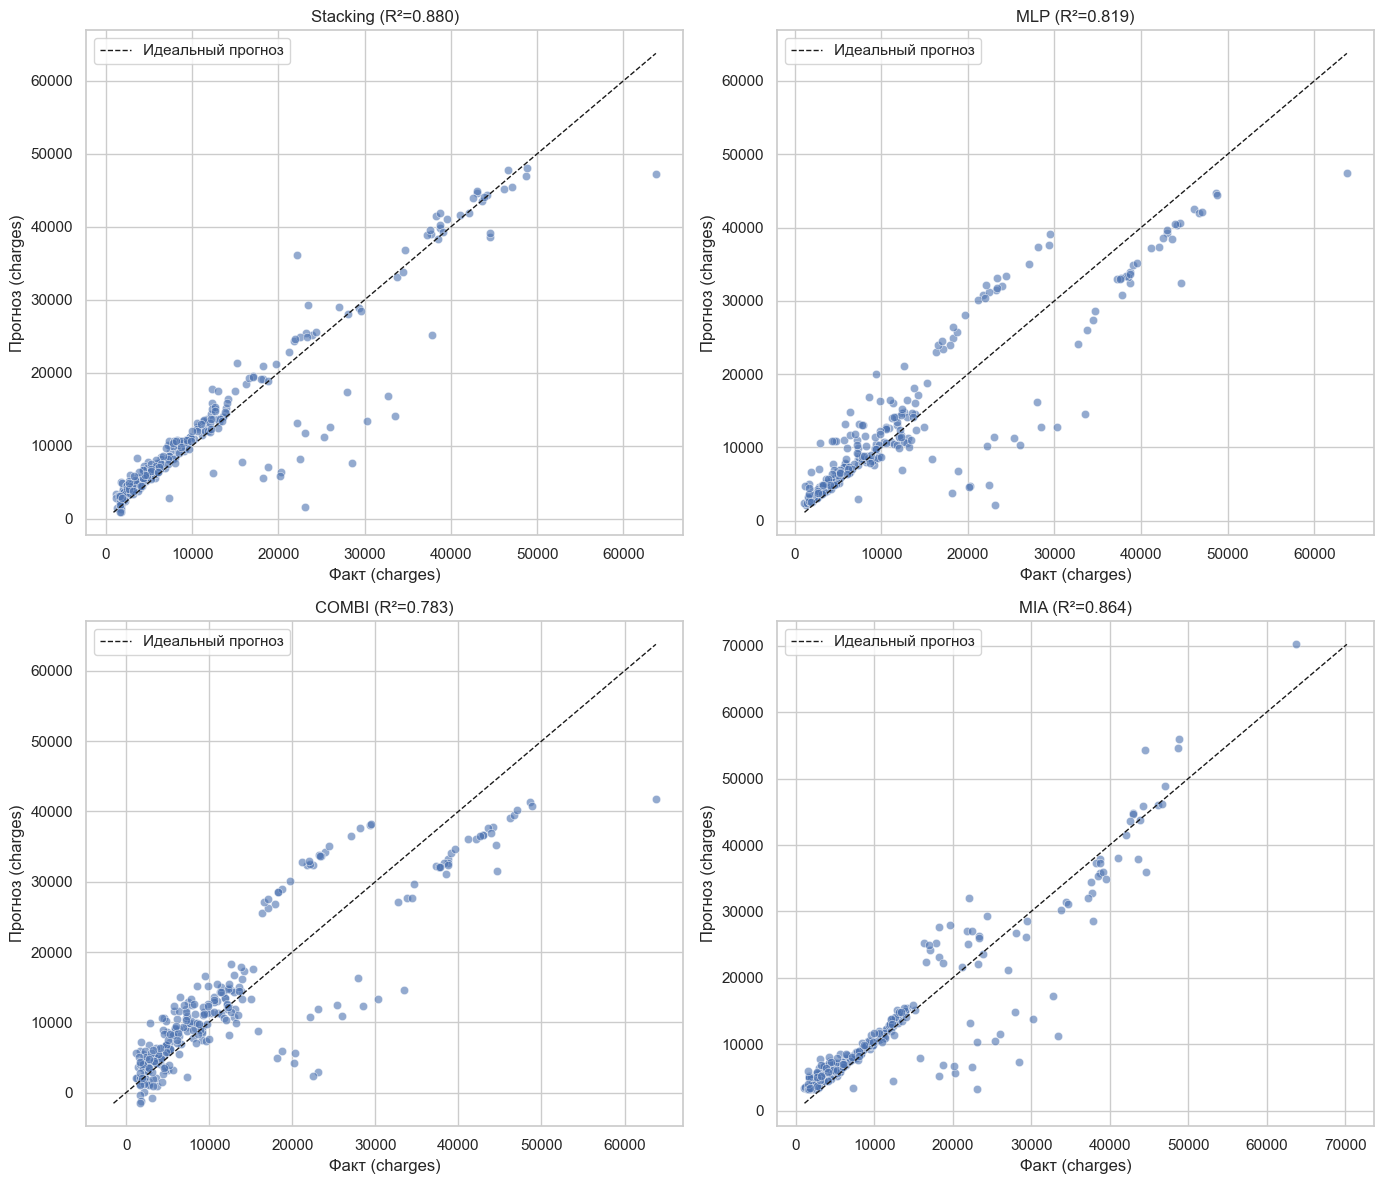

In [10]:
predictions = {
    'Stacking': pred_stack,
    'MLP': pred_mlp,
    'COMBI': pred_combi,
    'MIA': pred_mia,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (name, pred) in zip(axes.ravel(), predictions.items()):
    plot_actual_vs_pred(y_test, pred, f'{name} (R²={r2_score(y_test, pred):.3f})', ax=ax)
plt.tight_layout()
plt.show()

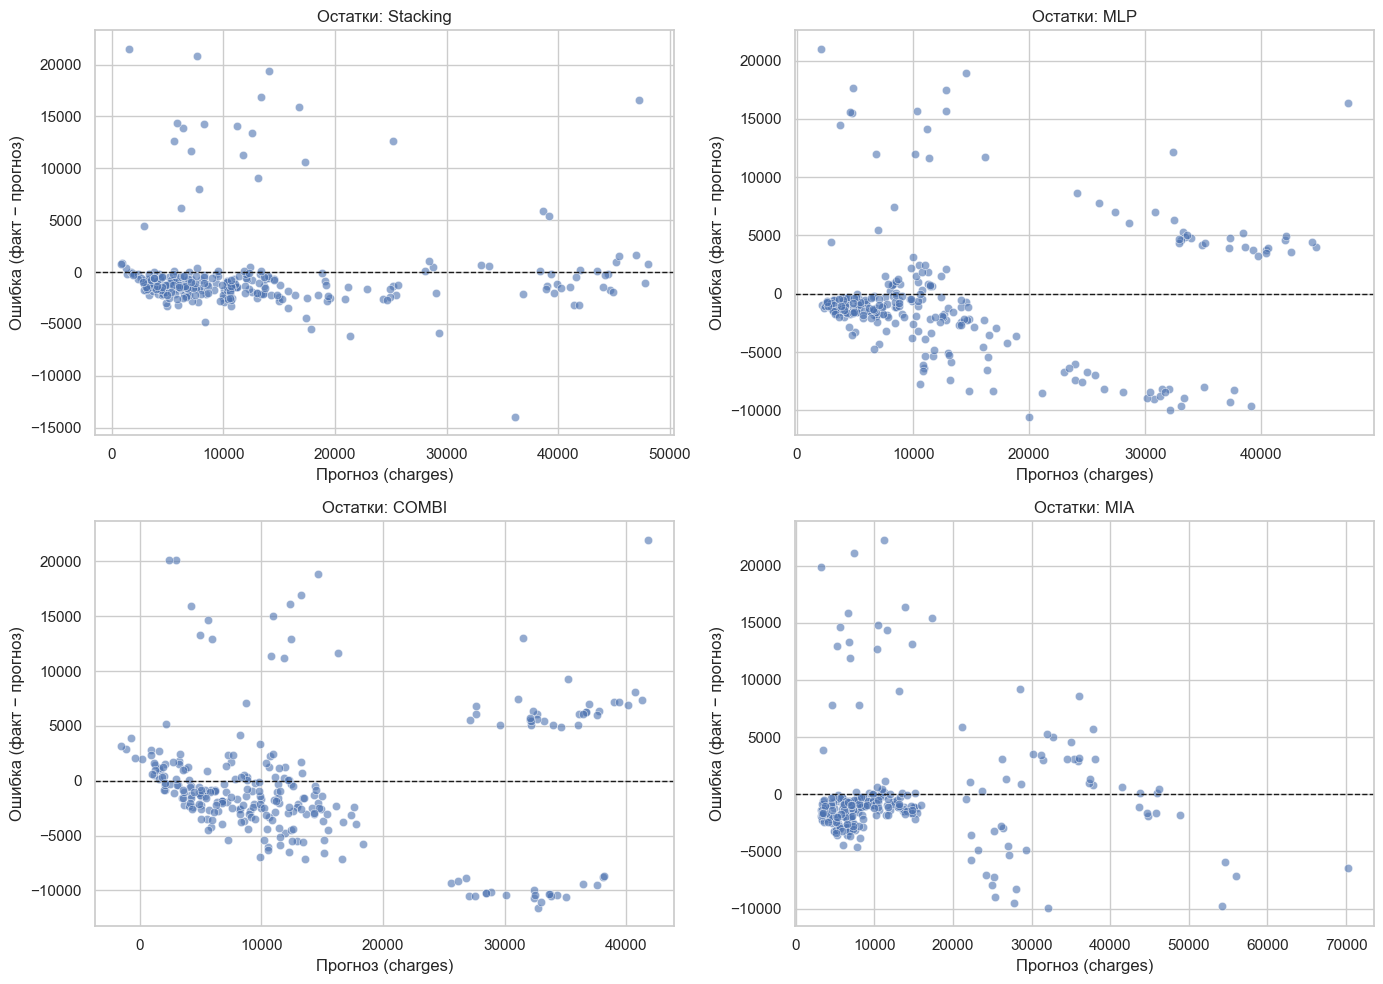

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, pred) in zip(axes.ravel(), predictions.items()):
    plot_residuals(y_test, pred, f'Остатки: {name}', ax=ax)
plt.tight_layout()
plt.show()

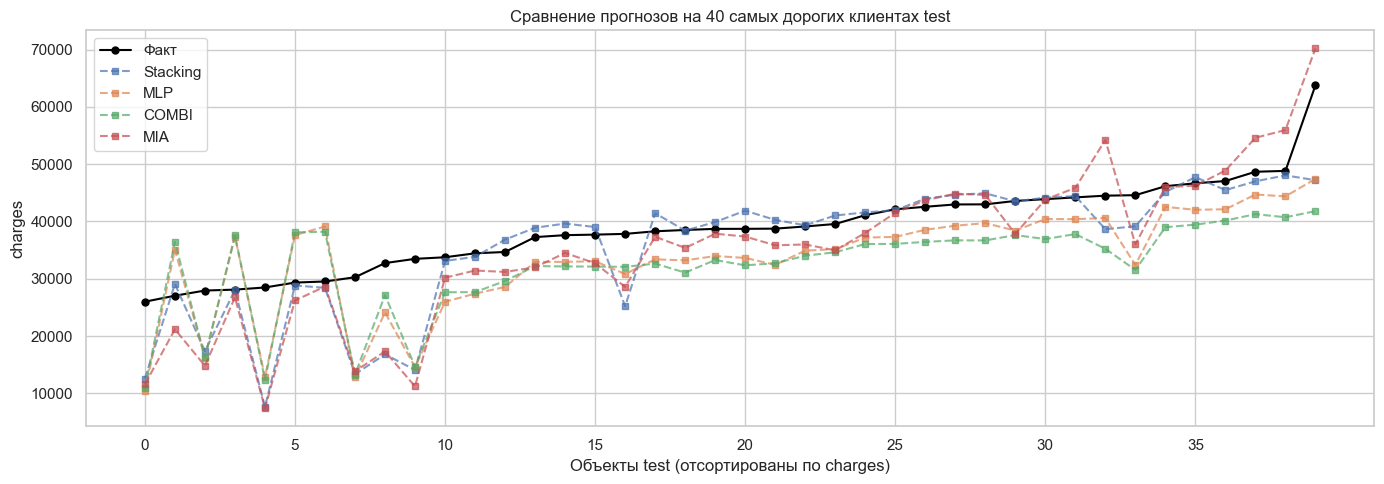

In [12]:
n_show = 40
idx = np.argsort(y_test)[-n_show:]

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(n_show)
ax.plot(x, y_test[idx], 'o-', color='black', label='Факт', markersize=5)
for name, pred in predictions.items():
    ax.plot(x, pred[idx], 's--', alpha=0.7, label=name, markersize=4)
ax.set_xticks(x[::5])
ax.set_xticklabels([f'{i}' for i in x[::5]])
ax.set_xlabel('Объекты test (отсортированы по charges)')
ax.set_ylabel('charges')
ax.set_title(f'Сравнение прогнозов на {n_show} самых дорогих клиентах test')
ax.legend()
plt.tight_layout()
plt.show()

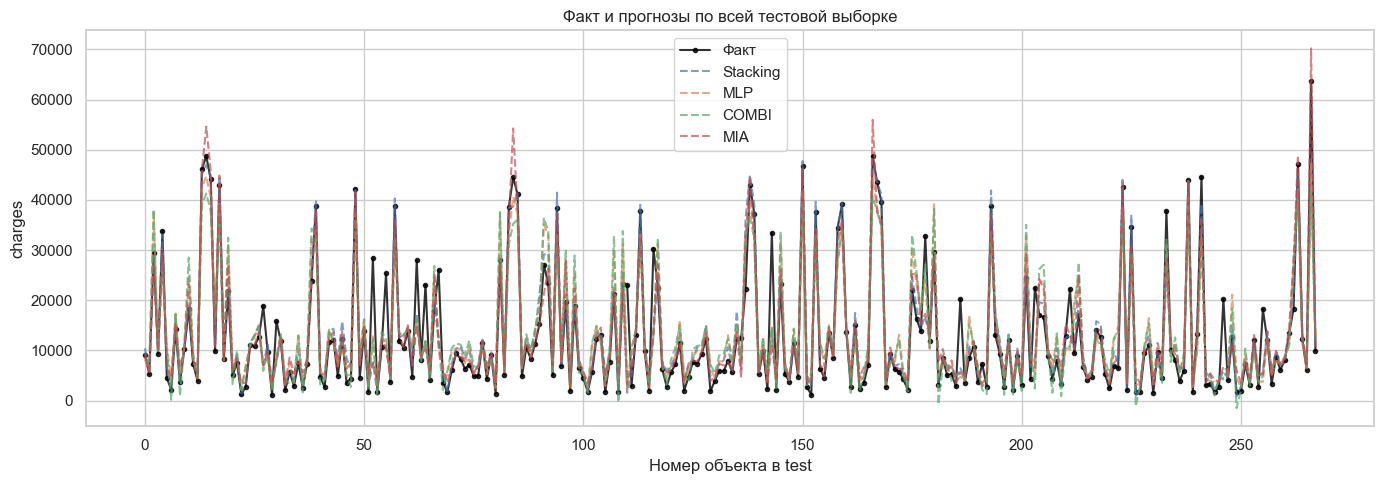

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(y_test))
ax.plot(x, y_test, 'o-', color='black', label='Факт', markersize=3, alpha=0.8)
for name, pred in predictions.items():
    ax.plot(x, pred, '--', alpha=0.7, label=name)
ax.set_xlabel('Номер объекта в test')
ax.set_ylabel('charges')
ax.set_title('Факт и прогнозы по всей тестовой выборке')
ax.legend()
plt.tight_layout()
plt.show()

## Сравнение моделей

In [14]:
results = pd.DataFrame([
    {'Модель': 'Stacking', **metrics_stack},
    {'Модель': 'MLP', **metrics_mlp},
    {'Модель': 'COMBI', **metrics_combi},
    {'Модель': 'MIA', **metrics_mia},
]).set_index('Модель')
results.sort_values('RMSE')

,RMSE,MAE,R2
Модель,,,
Stacking,4308.662056,2411.422393,0.880420
MIA,4591.448174,2760.980088,0.864209
MLP,5298.491867,3587.511006,0.819168
COMBI,5801.725755,4140.575944,0.783186


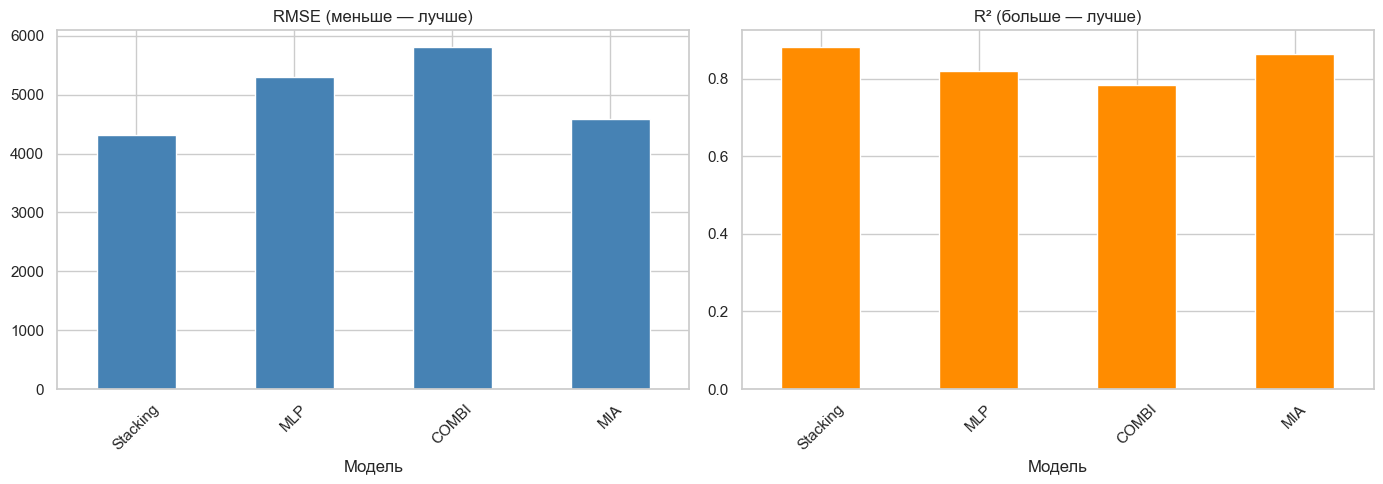

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results['RMSE'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('RMSE (меньше — лучше)')
axes[0].tick_params(axis='x', rotation=45)

results['R2'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('R² (больше — лучше)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

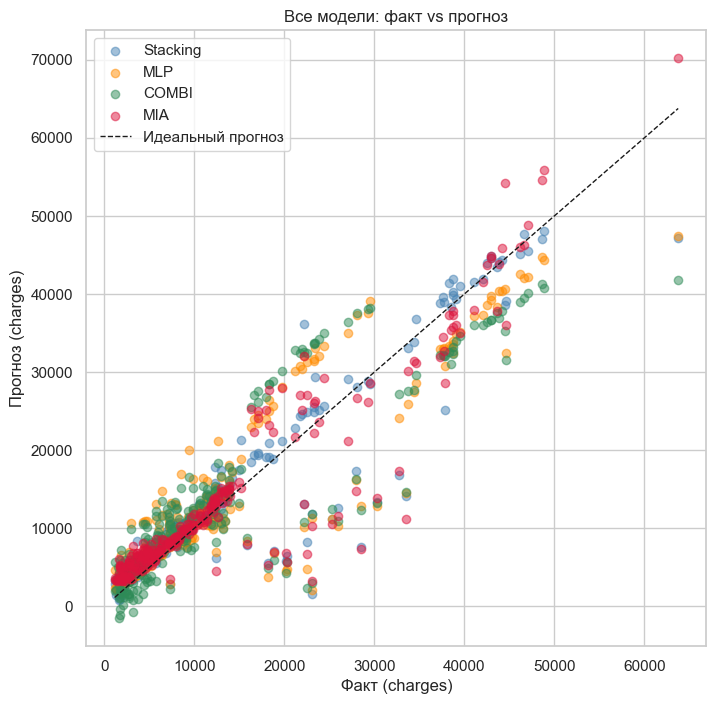

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']
for (name, pred), color in zip(predictions.items(), colors):
    ax.scatter(y_test, pred, alpha=0.5, label=name, color=color)
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'k--', lw=1, label='Идеальный прогноз')
ax.set_xlabel('Факт (charges)')
ax.set_ylabel('Прогноз (charges)')
ax.legend()
ax.set_title('Все модели: факт vs прогноз')
plt.show()